# neural_paw_dft demo: bcc Fe → predicted densities, augmentation occupancies, CHGCAR

A minimal walk-through of the inference pipeline on a two-atom cell:

1. CHGNet per-site moments (INCAR `MAGMOM`, and the net-moment constraint for the spin model)
2. ELECTRAFI total and spin density grids
3. AugNet PAW augmentation occupancies (total and magnetization channel)
4. Assemble everything into a VASP `CHGCAR`

Runs on CPU with a deliberately small FFT grid; expect a minute or two for model loading and the
first KeOps compile. Weights are downloaded from https://huggingface.co/faerte/neural_paw_dft on first use into
`trained_models/` (or `NDI_WEIGHTS_DIR`).

In [1]:
import numpy as np
from pymatgen.core import Lattice, Structure

from neural_paw_dft.pipeline import Pipeline, PipelineConfig

np.set_printoptions(precision=4, suppress=True, linewidth=120)

structure = Structure(Lattice.cubic(2.87), ["Fe", "Fe"], [[0, 0, 0], [0.5, 0.5, 0.5]])
GRID = (20, 20, 20)
print(structure)

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


Full Formula (Fe2)
Reduced Formula: Fe
abc   :   2.870000   2.870000   2.870000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (2)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Fe    0    0    0
  1  Fe    0.5  0.5  0.5


## Configure and run the pipeline

Everything is default except the device, the grid, and skipping the POTCAR directory (no VASP
POTCARs are needed to *predict*; NELECT then comes from the Materials Project POTCAR table).

In [2]:
cfg = PipelineConfig(device="cpu", grid_dims=GRID)
pipe = Pipeline(cfg)
pred = pipe.predict(structure)   # accepts a Structure, a POSCAR/CIF path, or a CHGCAR path
pred.meta

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu


{'input': '<Structure>',
 'electrafi': 'electrafi_spin_constrained',
 'augnet_total': 'augnet_total_full',
 'augnet_mag': 'augnet_spin_full',
 'chgnet': True,
 'device': 'cpu'}

## 1. CHGNet site moments and the spin constraint

In [3]:
print("per-site |m| (mu_B):", pred.site_moments)
print("net-moment constraint passed to ELECTRAFI (sum of unsigned moments):", round(pred.m_total, 4))

per-site |m| (mu_B): [2.5135 2.5135]
net-moment constraint passed to ELECTRAFI (sum of unsigned moments): 5.027


## 2. Densities

Grids are in e/Å³ (VASP's CHGCAR stores ρ·V_cell; the writer converts). The total density is
normalised exactly to NELECT; the spin density integrates to the constraint above whenever
|m| ≥ 0.1 μB.

In [4]:
V = structure.volume
dv = V / np.prod(GRID)
rho, spin = pred.rho_total, pred.rho_spin
print("grid:", rho.shape, "  NELECT:", pred.nelect)
print(f"total density:  integral {rho.sum()*dv:.4f} e   min {rho.min():.4f}  max {rho.max():.4f} e/Å³")
print(f"spin density:   integral {spin.sum()*dv:.4f} μB  min {spin.min():.4f}  max {spin.max():.4f} e/Å³")
print()
print("total density, z = 0 plane (first 6x6 points):")
print(rho[:6, :6, 0])
print()
print("spin density along the cube diagonal (atom at origin -> atom at body centre):")
print(np.array([spin[i, i, i] for i in range(GRID[0] // 2 + 1)]))

grid: (20, 20, 20)   NELECT: 28.0
total density:  integral 28.0000 e   min 0.2310  max 20.5517 e/Å³
spin density:   integral 5.0270 μB  min -0.0247  max 4.9050 e/Å³

total density, z = 0 plane (first 6x6 points):
[[20.5517 18.9758 14.7945  9.3978  4.6352  1.7196]
 [18.9921 17.5293 13.6053  8.5635  4.2022  1.5603]
 [14.8114 13.6307 10.4406  6.4362  3.0855  1.1426]
 [ 9.4402  8.5997  6.4517  3.861   1.7919  0.7339]
 [ 4.6807  4.2341  3.0882  1.7905  0.8881  0.497 ]
 [ 1.7373  1.5652  1.1367  0.7396  0.5015  0.3812]]

spin density along the cube diagonal (atom at origin -> atom at body centre):
[4.8664 3.6497 1.5029 0.2979 0.0516 0.0118 0.0506 0.285  1.4912 3.6492 4.905 ]


### Plots

Left: total density (one hue, light → dark for magnitude). Right: spin density on the same plane,
diverging around zero (grey = no polarization). Both are the z = 0 plane, which contains the
atom at the origin; the second atom sits half a cell above it. Below: line profiles along the
body diagonal, which passes through both atoms.

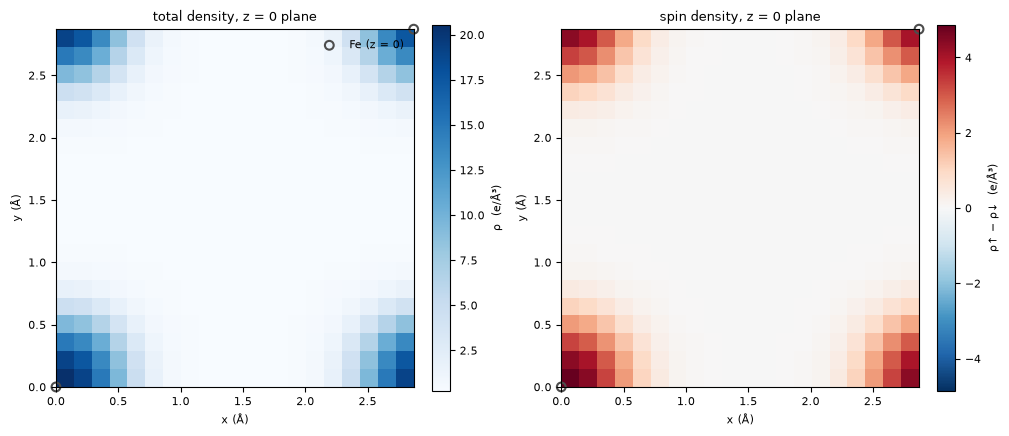

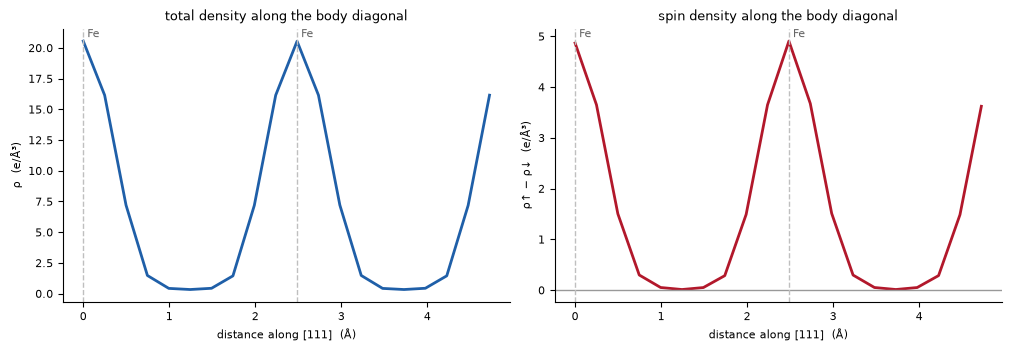

In [5]:
import matplotlib.pyplot as plt

a = structure.lattice.a
extent = [0, a, 0, a]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

im0 = axes[0].imshow(rho[:, :, 0].T, origin="lower", extent=extent, cmap="Blues")
axes[0].set_title("total density, z = 0 plane")
fig.colorbar(im0, ax=axes[0], label="ρ  (e/Å³)")

vmax = np.abs(spin[:, :, 0]).max()
im1 = axes[1].imshow(spin[:, :, 0].T, origin="lower", extent=extent, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("spin density, z = 0 plane")
fig.colorbar(im1, ax=axes[1], label="ρ↑ − ρ↓  (e/Å³)")

for ax in axes:
    ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)")
    ax.scatter([0, a], [0, a], s=40, facecolor="none", edgecolor="0.3", lw=1.5, label="Fe (z = 0)", clip_on=False)
axes[0].legend(loc="upper right", frameon=False)
plt.show()

# line profiles along the body diagonal through both atoms
n = GRID[0]
idx_diag = np.arange(n)
s_diag = idx_diag / n * a * np.sqrt(3)          # distance along the diagonal (Å)
rho_diag = rho[idx_diag, idx_diag, idx_diag]
spin_diag = spin[idx_diag, idx_diag, idx_diag]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
ax[0].plot(s_diag, rho_diag, lw=2, color="#1f5fa8"); ax[0].set_ylabel("ρ  (e/Å³)")
ax[1].plot(s_diag, spin_diag, lw=2, color="#b2182b"); ax[1].set_ylabel("ρ↑ − ρ↓  (e/Å³)")
ax[1].axhline(0, color="0.6", lw=1)
for k, (axi, title) in enumerate(zip(ax, ("total density", "spin density"))):
    axi.set_title(f"{title} along the body diagonal")
    axi.set_xlabel("distance along [111]  (Å)")
    for pos in (0, a * np.sqrt(3) / 2):
        axi.axvline(pos, color="0.75", lw=1, ls="--")
    axi.text(a * np.sqrt(3) / 2, axi.get_ylim()[1], " Fe", va="top", color="0.4")
    axi.text(0, axi.get_ylim()[1], " Fe", va="top", color="0.4")
    axi.spines[["top", "right"]].set_visible(False)
plt.show()

### 3D view

Interactive isosurfaces over the whole cell (drag to rotate). Left: three nested levels of the
total density. Right: the spin density at two positive levels; there is no negative lobe above
the chosen level in this cell. Grey spheres are the two Fe atoms.

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# grid points in Cartesian coordinates (cubic cell, so fractional * a)
fx, fy, fz = np.meshgrid(*[np.arange(n) / n for n in GRID], indexing="ij")
X, Y, Z = (fx * a).ravel(), (fy * a).ravel(), (fz * a).ravel()
atoms_xyz = structure.cart_coords

def atoms_trace():
    return go.Scatter3d(x=atoms_xyz[:, 0], y=atoms_xyz[:, 1], z=atoms_xyz[:, 2], mode="markers",
                        marker=dict(size=9, color="#555555"), name="Fe", showlegend=False)

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scene"}, {"type": "scene"}]],
                    subplot_titles=("total density  ρ (e/Å³)", "spin density  ρ↑−ρ↓ (e/Å³)"))

fig.add_trace(go.Isosurface(
    x=X, y=Y, z=Z, value=rho.ravel(),
    isomin=0.5, isomax=8.0, surface_count=3, opacity=0.35,
    colorscale="Blues", caps=dict(x_show=False, y_show=False, z_show=False),
    colorbar=dict(title="ρ", x=0.44, len=0.7)), row=1, col=1)
fig.add_trace(atoms_trace(), row=1, col=1)

fig.add_trace(go.Isosurface(
    x=X, y=Y, z=Z, value=spin.ravel(),
    isomin=0.2, isomax=2.0, surface_count=2, opacity=0.4,
    colorscale="Reds", caps=dict(x_show=False, y_show=False, z_show=False),
    colorbar=dict(title="ρ↑−ρ↓", x=1.0, len=0.7)), row=1, col=2)
fig.add_trace(atoms_trace(), row=1, col=2)

scene = dict(xaxis_title="x (Å)", yaxis_title="y (Å)", zaxis_title="z (Å)", aspectmode="cube",
             camera=dict(eye=dict(x=1.6, y=1.4, z=1.1)))
fig.update_layout(scene=scene, scene2=scene, width=1000, height=480, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

## 3. Augmentation occupancies

One block per ion in CHGCAR ("Sanvito") order, with the block length fixed by the POTCAR
(138 values for `Fe_pv`). Components with L > LMAXMIX would be zeroed when building a full input
set; `predict()` alone emits the whole block.

In [7]:
for i, blk in pred.aug_total.items():
    print(f"ion {i} ({structure[i-1].specie}) total-channel block: {blk.size} values, "
          f"|max| {np.abs(blk).max():.4f}, first 10: {blk[:10]}")
for i, blk in pred.aug_diff.items():
    print(f"ion {i} ({structure[i-1].specie}) magnetization block: {blk.size} values, "
          f"|max| {np.abs(blk).max():.4f}, first 10: {blk[:10]}")

ion 1 (Fe) total-channel block: 138 values, |max| 1.9029, first 10: [ 1.7016  0.     -0.      0.      0.      0.      0.1132 -0.     -0.      0.    ]
ion 2 (Fe) total-channel block: 138 values, |max| 1.9029, first 10: [ 1.7016  0.      0.     -0.      0.      0.      0.1132 -0.     -0.      0.    ]
ion 1 (Fe) magnetization block: 138 values, |max| 0.7753, first 10: [-0.0143 -0.      0.      0.     -0.     -0.     -0.0301  0.     -0.      0.    ]
ion 2 (Fe) magnetization block: 138 values, |max| 0.7753, first 10: [-0.0143 -0.      0.      0.     -0.      0.     -0.0301  0.     -0.      0.    ]


## 4. Write the CHGCAR

`build_chgcar` writes total grid, total augmentation, the per-ion moment line VASP expects,
the spin grid and the spin augmentation, then fixes pymatgen's augmentation headers to VASP's
fixed-width format. (`Pipeline.build(...)` does this plus INCAR/POSCAR/POTCAR/KPOINTS.)

In [8]:
from pathlib import Path
from pymatgen.io.vasp.outputs import Chgcar
from neural_paw_dft.pipeline.assemble import build_chgcar

out = Path("demo_out"); out.mkdir(exist_ok=True)
path = build_chgcar(structure, pred.rho_total, pred.rho_spin, pred.aug_total, pred.aug_diff,
                    pred.site_moments, out / "CHGCAR", nelect=pred.nelect)

chg = Chgcar.from_file(str(path))
print("wrote", path, f"({path.stat().st_size/1e6:.1f} MB)")
print("spin polarized:", chg.is_spin_polarized, " grid:", chg.dim)
print("integral of total:", chg.data['total'].sum() / chg.data['total'].size)
print("integral of diff: ", chg.data['diff'].sum() / chg.data['diff'].size)
print("aug blocks:", {k: v.size for k, v in chg.data_aug['total'].items()})
print()
print("\n".join(open(path).read().splitlines()[:12]))

wrote demo_out/CHGCAR (0.3 MB)
spin polarized: True  grid: (20, 20, 20)
integral of total: 28.0000003179692
integral of diff:  5.0269630866836446
aug blocks: {1: 138, 2: 138}

VolumetricData
   1.00000000000000
     2.870000    0.000000    0.000000
     0.000000    2.870000    0.000000
     0.000000    0.000000    2.870000
Fe   
     2
Direct
  0.000000  0.000000  0.000000
  0.500000  0.500000  0.500000
 
   20   20   20
